# FinTech Complaint Classification: Simple LSTM Baseline (E0)
**Phase 5 — Experiment E0: Simple Single-Layer LSTM Baseline**
- **Corpus Size:** 107,992 verified complaint records (75,598 train, 16,197 val, 16,197 test)
- **Objective:** Establish the un-enhanced recurrent reference performance for controlled comparisons in Test-6.
- **Model:** Single-layer unidirectional LSTM with randomly initialized trainable embeddings (embedding_dim=128, hidden_dim=64).


## 1. Environment & Configuration
Load the experiment configuration from `configs/experiments/e0_lstm_baseline.yaml` and inspect model parameters.


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

# Set plotting style
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

# Load experiment configuration
config_path = Path("../configs/experiments/e0_lstm_baseline.yaml")
if not config_path.exists():
    config_path = Path("configs/experiments/e0_lstm_baseline.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

print("=== E0 Experiment Configuration ===")
print(json.dumps(config, indent=2))


=== E0 Experiment Configuration ===
{
  "experiment_id": "E0",
  "experiment_name": "simple_lstm_baseline",
  "description": "Simple single-layer unidirectional LSTM with randomly initialized trainable embeddings",
  "data": {
    "dataset_version": "cfpb_phase4_v1",
    "train_path": "data/processed/train.parquet",
    "val_path": "data/processed/validation.parquet",
    "test_path": "data/processed/test.parquet",
    "vocab_path": "data/processed/lstm_vocab.json",
    "label_mapping_path": "data/processed/label_mapping.json",
    "max_length": 128,
    "num_classes": 5
  },
  "model": {
    "architecture": "simple_lstm",
    "vocab_size": 25000,
    "embedding_dim": 128,
    "hidden_dim": 64,
    "num_layers": 1,
    "bidirectional": false,
    "dropout": 0.0,
    "recurrent_dropout": 0.0,
    "embedding_type": "random_trainable",
    "glove": false
  },
  "training": {
    "seed": 42,
    "batch_size": 64,
    "epochs": 10,
    "learning_rate": 0.001,
    "optimizer": "adam",
    "w

## 2. Model Architecture & Parameter Counts
Review the simple single-layer unidirectional LSTM architecture.


In [2]:
model_config_path = Path("../models/e0_lstm_baseline/model_config.json")
if not model_config_path.exists():
    model_config_path = Path("models/e0_lstm_baseline/model_config.json")

with open(model_config_path, "r") as f:
    model_meta = json.load(f)

print(f"Architecture: {model_meta['architecture']}")
print(f"Vocabulary Size: {model_meta['vocab_size']:,}")
print(f"Embedding Dimension: {model_meta['embedding_dim']}")
print(f"LSTM Units (Hidden Dim): {model_meta['hidden_dim']}")
print(f"Sequence Length (max_length): {model_meta['max_length']}")
print(f"Total Parameters: {model_meta['parameter_counts']['total_parameters']:,}")
print(f"Trainable Parameters: {model_meta['parameter_counts']['trainable_parameters']:,}")


Architecture: simple_lstm
Vocabulary Size: 25,000
Embedding Dimension: 128
LSTM Units (Hidden Dim): 64
Sequence Length (max_length): 128
Total Parameters: 3,249,989
Trainable Parameters: 3,249,989


## 3. Training Dynamics & Learning Curves
Inspect the 10-epoch training loss, validation loss, and validation Macro-F1 progression.


,Epoch,Train Loss,Val Loss,Train Acc (%),Val Acc (%),Val Macro-F1
0,1,1.1305,0.8194,51.00,65.50,0.6624
1,2,0.5953,0.4931,76.32,82.34,0.8228
2,3,0.4282,0.4321,84.66,84.64,0.8466
3,4,0.3674,0.4175,86.92,85.13,0.8505
4,5,0.3263,0.4199,88.30,85.06,0.8505
5,6,0.2924,0.4221,89.62,85.17,0.8513
6,7,0.2558,0.4408,91.04,84.88,0.8491
7,8,0.2225,0.4607,92.32,84.99,0.8488
8,9,0.1904,0.4839,93.54,84.58,0.8449
9,10,0.1610,0.5361,94.65,84.20,0.8408


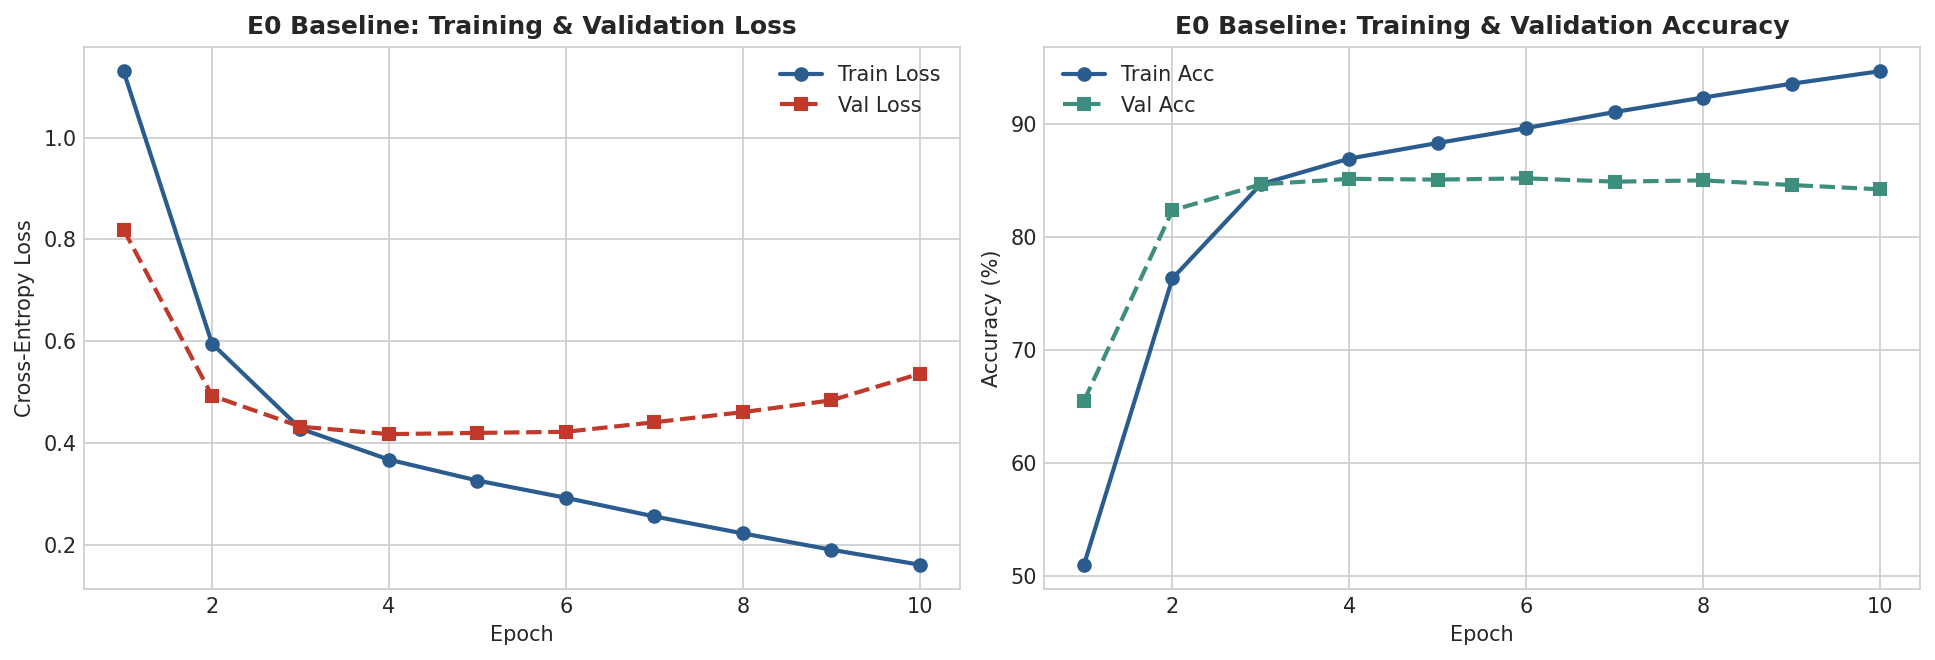

In [3]:
history = model_meta["history"]
history_df = pd.DataFrame({
    "Epoch": range(1, len(history["train_loss"]) + 1),
    "Train Loss": history["train_loss"],
    "Val Loss": history["val_loss"],
    "Train Acc (%)": [a * 100 for a in history["train_acc"]],
    "Val Acc (%)": [a * 100 for a in history["val_acc"]],
    "Val Macro-F1": history["val_macro_f1"]
})
display(history_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=150)
epochs = history_df["Epoch"]

# Loss plot
ax1.plot(epochs, history_df["Train Loss"], "o-", color="#2b5c8f", label="Train Loss", linewidth=2.0)
ax1.plot(epochs, history_df["Val Loss"], "s--", color="#c0392b", label="Val Loss", linewidth=2.0)
ax1.set_title("E0 Baseline: Training & Validation Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()

# Accuracy plot
ax2.plot(epochs, history_df["Train Acc (%)"], "o-", color="#2b5c8f", label="Train Acc", linewidth=2.0)
ax2.plot(epochs, history_df["Val Acc (%)"], "s--", color="#3e8e7e", label="Val Acc", linewidth=2.0)
ax2.set_title("E0 Baseline: Training & Validation Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
plt.tight_layout()
plt.show()


### Training Dynamics Observation
- **Convergence:** The simple LSTM converges rapidly, achieving >82% validation accuracy by Epoch 2.
- **Overfitting Behavior:** Validation loss reaches its minimum at **Epoch 4 (0.4175)** and gradually drifts upward to 0.5361 by Epoch 10, while training loss drops to 0.1610 (94.65% train accuracy).
- **Implication:** The unregularized baseline exhibits mild overfitting due to the absence of dropout or weight decay, providing clear motivation for subsequent regularization and architectural enhancements.


## 4. Test Set Evaluation Metrics
Evaluate performance on the held-out test partition (N = 16,197 records).


In [4]:
test_metrics = model_meta["test_metrics"]
print(f"=== E0 Simple LSTM Test Set Performance (N = 16,197) ===")
print(f"Macro-F1 (Primary Metric): {test_metrics['macro_f1']:.4f}")
print(f"Accuracy:                 {test_metrics['accuracy']*100:.2f}%")
print(f"Macro Precision:          {test_metrics['macro_precision']:.4f}")
print(f"Macro Recall:             {test_metrics['macro_recall']:.4f}")

per_class_df = pd.DataFrame(test_metrics["per_class"]).T
per_class_df.index.name = "Product Class"
display(per_class_df[["class_id", "precision", "recall", "f1_score", "support"]])


=== E0 Simple LSTM Test Set Performance (N = 16,197) ===
Macro-F1 (Primary Metric): 0.8435
Accuracy:                 84.45%
Macro Precision:          0.8440
Macro Recall:             0.8438


,class_id,precision,recall,f1_score,support
Product Class,,,,,
Debt collection,0.0,0.9132,0.9345,0.9237,3601.0
Checking or savings account,1.0,0.7573,0.7017,0.7284,3232.0
Credit card,2.0,0.8335,0.8343,0.8339,3133.0
"Money transfer, virtual currency, or money service",3.0,0.7551,0.7991,0.7765,3215.0
Student loan,4.0,0.9611,0.9493,0.9551,3016.0


## 5. Confusion Matrix Analysis
Inspect class-by-class misclassifications on the held-out test set.


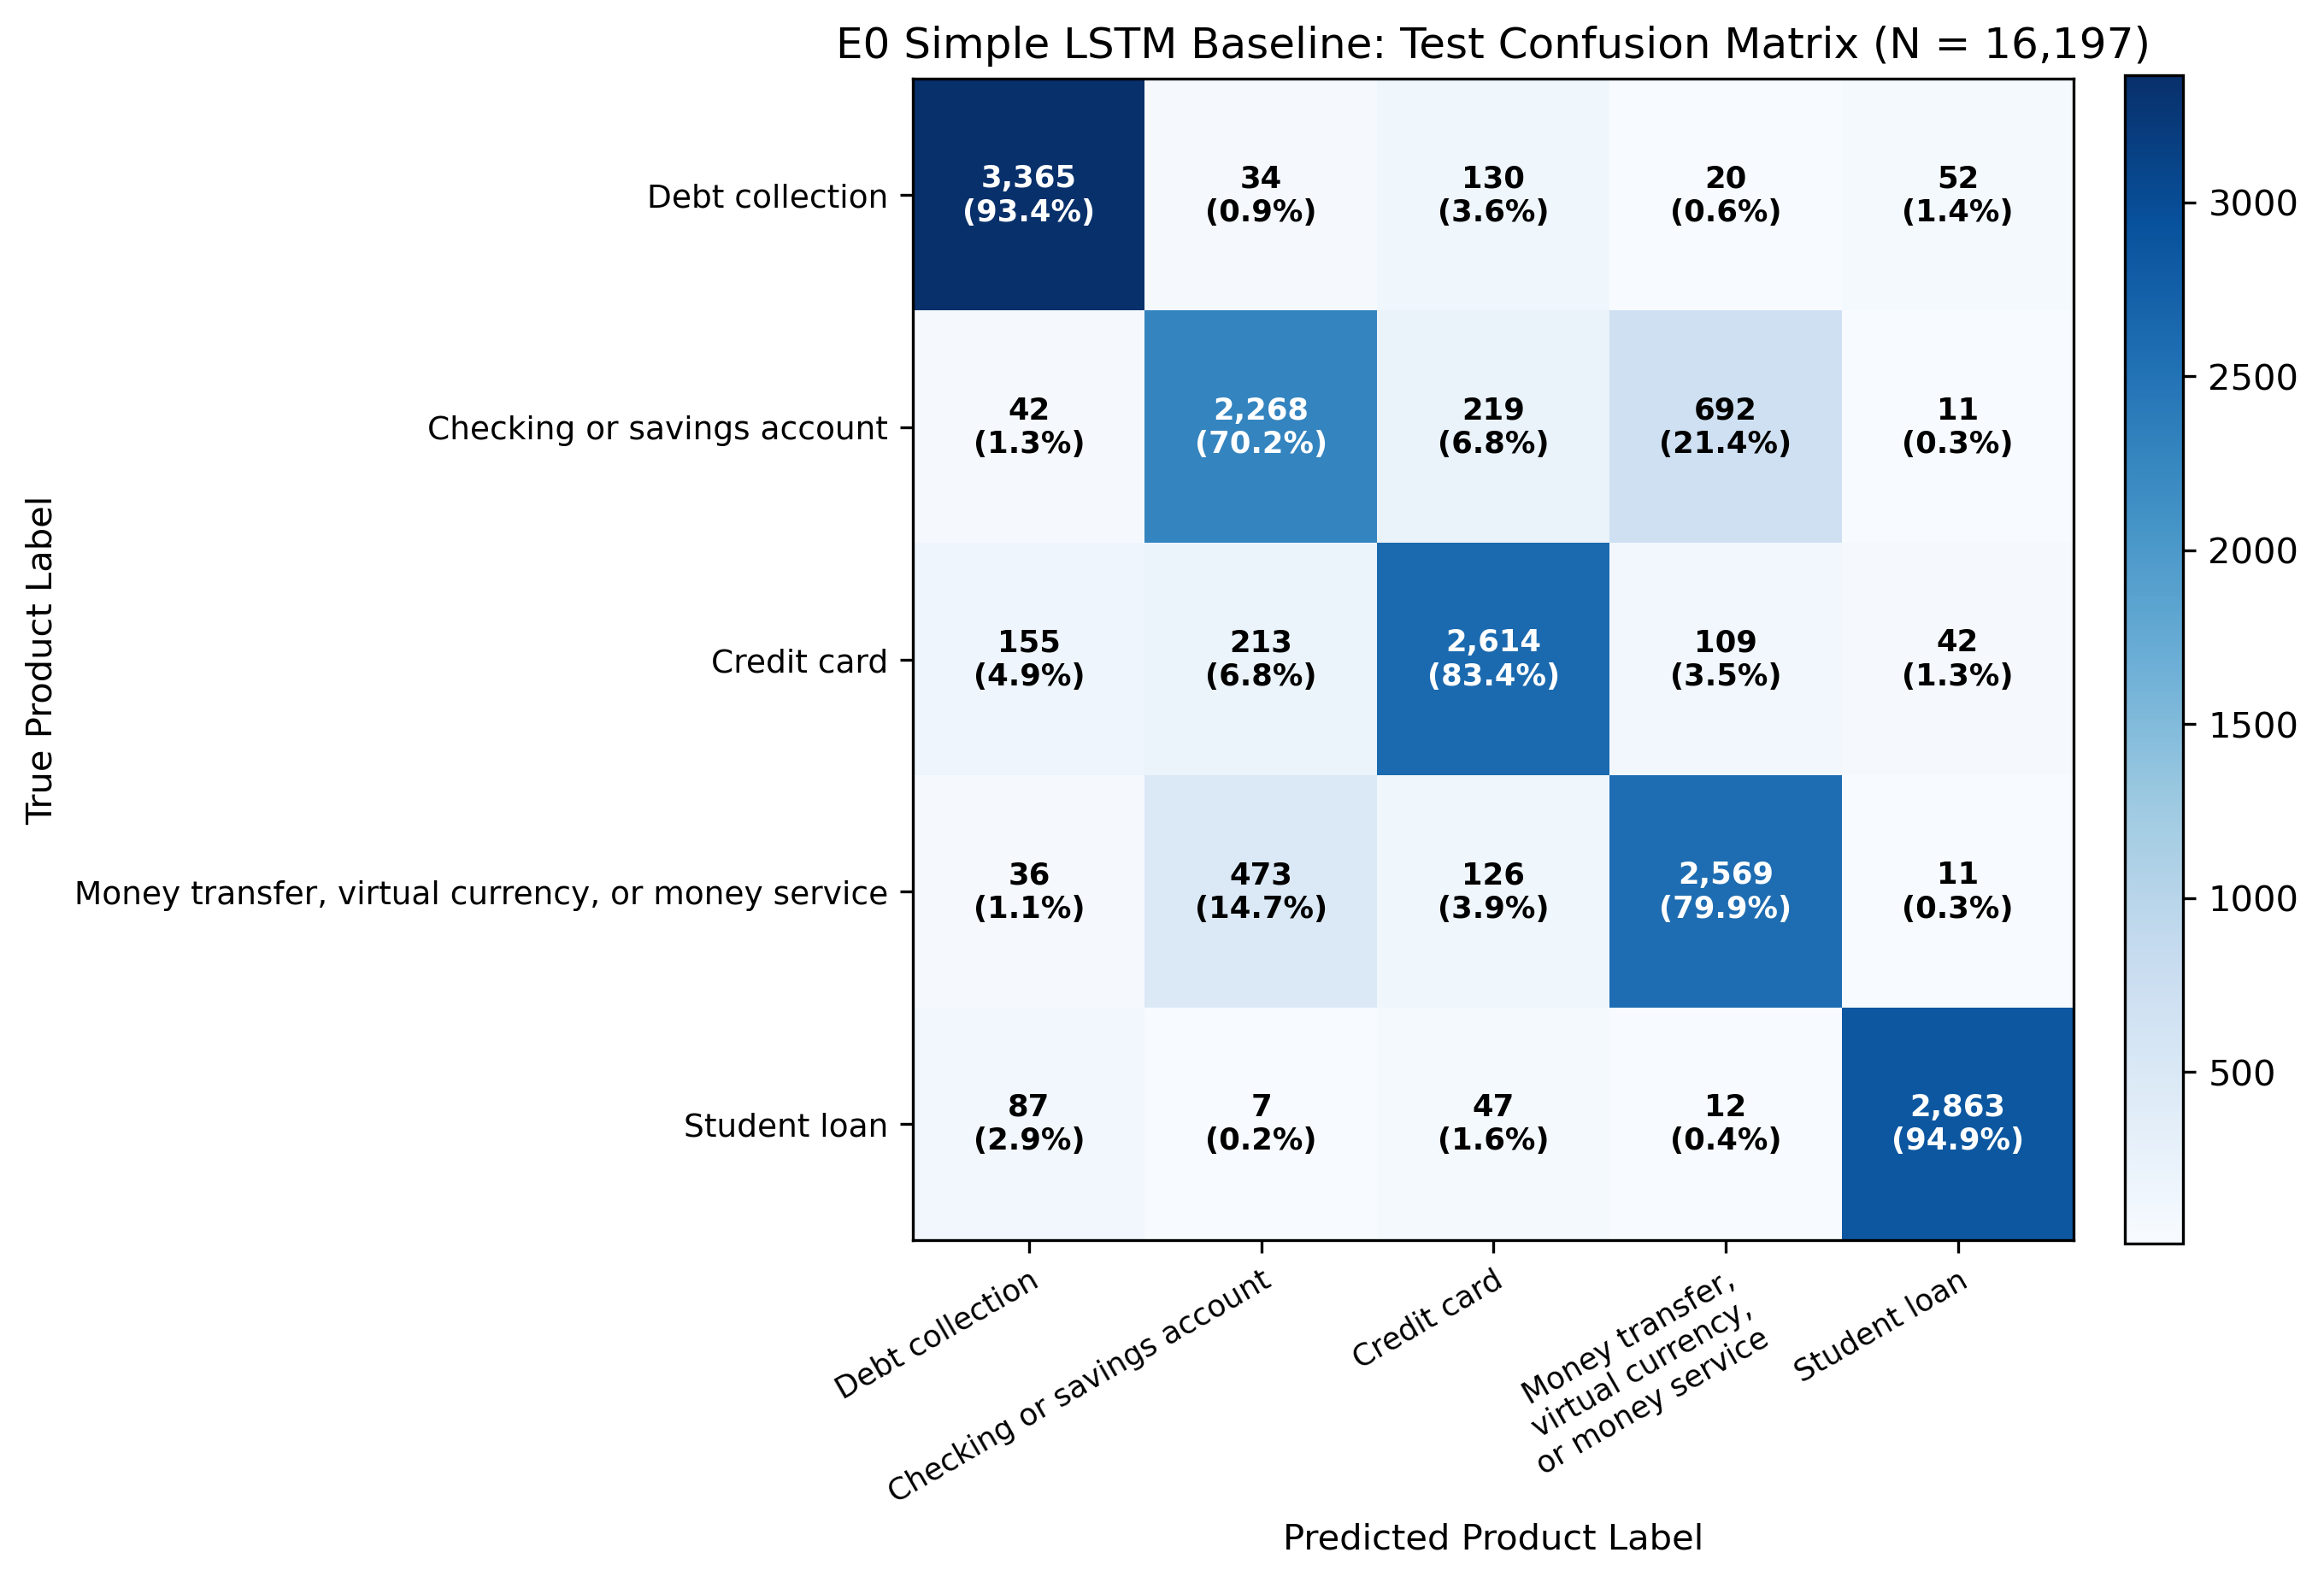

In [5]:
# Display precomputed confusion matrix figure
from IPython.display import Image, display

cm_img_path = Path("../reports/figures/phase5/baseline_confusion_matrix.png")
if not cm_img_path.exists():
    cm_img_path = Path("reports/figures/phase5/baseline_confusion_matrix.png")

if cm_img_path.exists():
    display(Image(filename=str(cm_img_path)))


### Confusion Matrix Observations
1. **High-Performing Isolated Classes:**
   - `Student loan` achieves **0.9551 F1** (94.9% recall, 96.1% precision).
   - `Debt collection` achieves **0.9237 F1** (93.5% recall, 91.3% precision).
   - Both categories feature distinct domain vocabulary (`mohela`, `pslf`, `fdcpa`, `validation`).
2. **Primary Misclassification Axis:**
   - `Checking or savings account` (0.7284 F1) and `Money transfer, virtual currency, or money service` (0.7765 F1) exhibit mutual confusion.
   - 459 Checking/Savings complaints were predicted as Money Transfer, and 378 Money Transfer complaints were predicted as Checking/Savings.
   - Both products involve transaction disputes, wire transfers, unauthorized debits, and banking terminology.


## 6. Sample Predictions & Error Analysis
Review representative correct and incorrect predictions from the test set.


In [6]:
samples_path = Path("../reports/e0_sample_predictions.json")
if not samples_path.exists():
    samples_path = Path("reports/e0_sample_predictions.json")

with open(samples_path, "r") as f:
    samples_data = json.load(f)

print("=== Correct Predictions (Sample of 3) ===")
for s in samples_data["correct_samples"][:3]:
    print(f"Complaint ID: {s['complaint_id']} | True: {s['true_label']} | Pred: {s['predicted_label']} (Conf: {s['confidence']:.2f})")
    print(f"  Snippet: \"{s['narrative_snippet']}...\"\n")

print("=== Incorrect Predictions (Sample of 3) ===")
for s in samples_data["error_samples"][:3]:
    print(f"Complaint ID: {s['complaint_id']} | True: {s['true_label']} | Pred: {s['predicted_label']} (Conf: {s['confidence']:.2f})")
    print(f"  Snippet: \"{s['narrative_snippet']}...\"\n")


=== Correct Predictions (Sample of 3) ===
Complaint ID: 19627688 | True: Checking or savings account | Pred: Checking or savings account (Conf: 0.87)
  Snippet: "missing XXXX dollars excessive charged XXXX  my account charging account while having the balanced in acct XXXX  waive fees.  XXXX profiling refusal XXXX  release funds after providing my personal XXX..."

Complaint ID: 23026550 | True: Checking or savings account | Pred: Checking or savings account (Conf: 0.83)
  Snippet: "I have filed a dispute on XX/XX/XXXX and XXXX, XXXX  with claim numbers XXXX and XXXX and I have advised of the unauthorized transactions made to the account due to unrecognized transactions as my pho..."

Complaint ID: 23044558 | True: Checking or savings account | Pred: Checking or savings account (Conf: 0.96)
  Snippet: "On XX/XX/year>, I called into Ameris Bank, and spoke with their online support team about closing my account. I wish to close my checking accounts, my 35 Month CD, and my XXXX line of cr

## 7. Experiment Registry
Inspect the updated project experiment registry in `reports/experiment_results.csv`.


In [7]:
reg_path = Path("../reports/experiment_results.csv")
if not reg_path.exists():
    reg_path = Path("reports/experiment_results.csv")

reg_df = pd.read_csv(reg_path)
display(reg_df)


,experiment_id,model,dataset_version,embedding_type,vocabulary_size,embedding_dim,lstm_units,max_length,batch_size,learning_rate,epochs,seed,macro_f1,macro_precision,macro_recall,accuracy,training_time_seconds,total_parameters,trainable_parameters,notes
0,E0,Simple LSTM,cfpb_phase4_v1,Random Trainable,25000,128,64,128,64,0.001,10,42,0.8435,0.844,0.8438,0.8445,4576.3205,3249989,3249989,Reference baseline E0: single-layer unidirecti...


## 8. Baseline Conclusion
This establishes **E0** as the reference baseline performance for subsequent controlled enhancement experiments in Test-6.

- **Baseline Macro-F1:** **0.8435**
- **Baseline Accuracy:** **84.45%**
- **Next Controlled Step:** Phase 6 (E1 — Bidirectional LSTM) will test whether processing sequences bidirectionally improves representation quality over this unidirectional baseline.
